# Session Clustering via K-Medoids

Use the pre-computed normalized Levenshtein distance matrix (unique-sequence level) to cluster sessions with K-Medoids. Evaluate k = 2..20, select the best k, visualize with t-SNE, and print representative examples.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_score
from sklearn_extra.cluster import KMedoids

import warnings

warnings.filterwarnings("ignore")

## 1. Load Pre-computed Data

In [2]:
DATA_DIR = Path("../data/clusters/distances")
MIN_MESSAGES = 4  # exclude sessions with <= 3 messages

# Distance matrix over unique sequences (n_unique x n_unique)
dist_matrix_unique = np.load(DATA_DIR / "distance_matrix.npy")
print(f"Unique distance matrix shape: {dist_matrix_unique.shape}")

# sha -> unique sequence index mapping
with open(DATA_DIR / "sha_to_sequence_idx.json") as f:
    sha_to_idx = json.load(f)

# Metadata
with open(DATA_DIR / "metadata.json") as f:
    metadata = json.load(f)

print(f"Total sessions: {metadata['n_sessions']}")
print(f"Unique sequences: {metadata['n_unique_sequences']}")
print(f"Parameters: {metadata['parameters']}")

# Count messages per session from classification data
clf_df = pd.read_csv(
    "../data/classifications/classifications_for_analysis.csv",
    usecols=["sha", "index_in_chat"],
)
msg_counts = clf_df.groupby("sha")["index_in_chat"].nunique()

# Filter: keep sessions with >= MIN_MESSAGES messages
valid_shas = set(msg_counts[msg_counts >= MIN_MESSAGES].index)
shas = sorted(sha for sha in sha_to_idx if sha in valid_shas)
n_filtered = len(sha_to_idx) - len(shas)
print(f"\nFiltered out {n_filtered} sessions with < {MIN_MESSAGES} messages")
print(f"Remaining sessions: {len(shas)}")

# Expand to session-level distance matrix
idx_array = np.array([sha_to_idx[sha] for sha in shas])
dist_matrix = dist_matrix_unique[np.ix_(idx_array, idx_array)]
print(f"Session-level distance matrix shape: {dist_matrix.shape}")

Unique distance matrix shape: (6787, 6787)
Total sessions: 11579
Unique sequences: 6787
Parameters: {'indel_weight': 1.0, 'same_parent_weight': 0.5, 'cross_parent_weight': 1.0, 'normalize': True}

Filtered out 6715 sessions with < 4 messages
Remaining sessions: 4864
Session-level distance matrix shape: (4864, 4864)


## 2. K-Medoids: Sweep k = 2..20

In [3]:
K_RANGE = range(2, 21)

results = []
fitted_models = {}

for k in K_RANGE:
    kmed = KMedoids(
        n_clusters=k,
        metric="precomputed",
        method="pam",
        init="k-medoids++",
        random_state=42,
        max_iter=100,
    )
    labels = kmed.fit_predict(dist_matrix)

    sil = silhouette_score(dist_matrix, labels, metric="precomputed")

    # Inertia analogue: sum of distances from each point to its medoid
    medoid_indices = kmed.medoid_indices_
    inertia = sum(dist_matrix[i, medoid_indices[labels[i]]] for i in range(len(labels)))

    results.append({"k": k, "silhouette": sil, "inertia": inertia})
    fitted_models[k] = kmed
    print(f"k={k:2d}  silhouette={sil:.4f}  inertia={inertia:.2f}")

df_results = pd.DataFrame(results)

k= 2  silhouette=0.0546  inertia=3551.54
k= 3  silhouette=0.0552  inertia=3426.89
k= 4  silhouette=0.0544  inertia=3327.40
k= 5  silhouette=0.0655  inertia=3244.45
k= 6  silhouette=0.0703  inertia=3162.29
k= 7  silhouette=0.0612  inertia=3117.75
k= 8  silhouette=0.0534  inertia=3076.88
k= 9  silhouette=0.0547  inertia=3042.98
k=10  silhouette=0.0523  inertia=3011.16
k=11  silhouette=0.0527  inertia=2981.76
k=12  silhouette=0.0543  inertia=2960.28
k=13  silhouette=0.0487  inertia=2927.83
k=14  silhouette=0.0479  inertia=2908.83
k=15  silhouette=0.0487  inertia=2892.02
k=16  silhouette=0.0395  inertia=2873.88
k=17  silhouette=0.0367  inertia=2858.22
k=18  silhouette=0.0417  inertia=2844.73
k=19  silhouette=0.0402  inertia=2830.99
k=20  silhouette=0.0397  inertia=2818.36


## 3. Evaluation Metrics

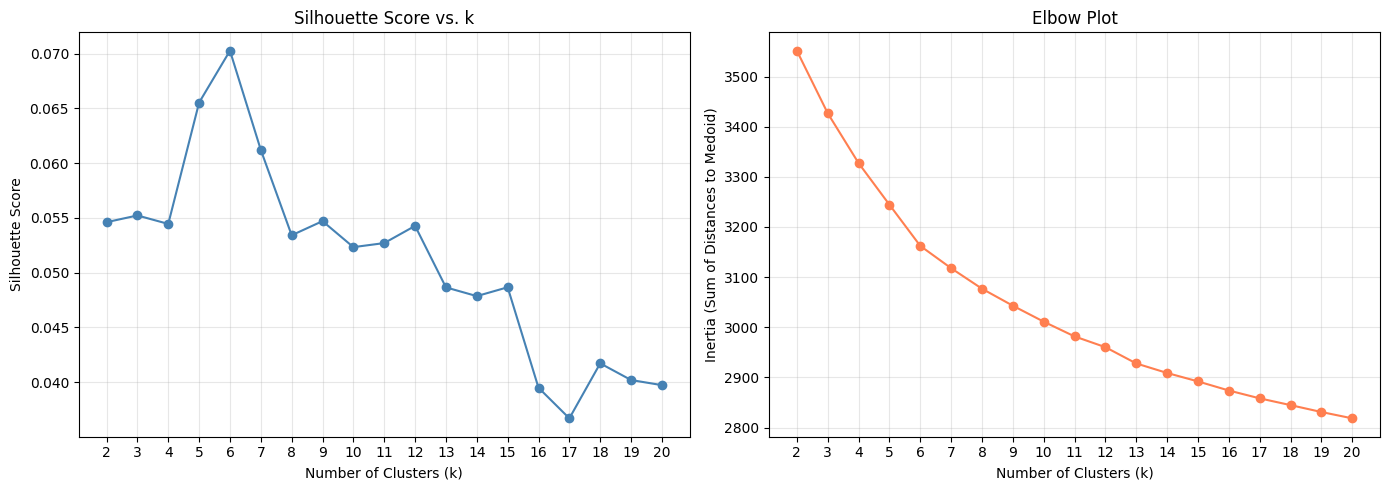

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Silhouette score
axes[0].plot(df_results["k"], df_results["silhouette"], "o-", color="steelblue")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Silhouette Score")
axes[0].set_title("Silhouette Score vs. k")
axes[0].set_xticks(list(K_RANGE))
axes[0].grid(True, alpha=0.3)

# Inertia (elbow plot)
axes[1].plot(df_results["k"], df_results["inertia"], "o-", color="coral")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Inertia (Sum of Distances to Medoid)")
axes[1].set_title("Elbow Plot")
axes[1].set_xticks(list(K_RANGE))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
# Select best k manually based on silhouette score and elbow plot
best_k = 6
print(f"Selected best k: {best_k}")
print(
    f"  Silhouette = {df_results[df_results['k'] == best_k]['silhouette'].values[0]:.4f}"
)

best_model = fitted_models[best_k]
best_labels = best_model.labels_
best_medoids = best_model.medoid_indices_

# Cluster size distribution
session_cluster_df = pd.DataFrame({"sha": shas, "cluster": best_labels})
print(f"\nCluster sizes (sessions):")
print(session_cluster_df["cluster"].value_counts().sort_index().to_string())

Selected best k: 6
  Silhouette = 0.0703

Cluster sizes (sessions):
cluster
0     767
1     968
2    1158
3     460
4     896
5     615


## 4. t-SNE Visualization

Project the precomputed distance matrix into 2D via t-SNE.

In [6]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    metric="precomputed",
    init="random",
    random_state=42,
    perplexity=30,
    max_iter=1000,
)
coords_2d = tsne.fit_transform(dist_matrix)
print(f"t-SNE embedding shape: {coords_2d.shape}")

t-SNE embedding shape: (4864, 2)


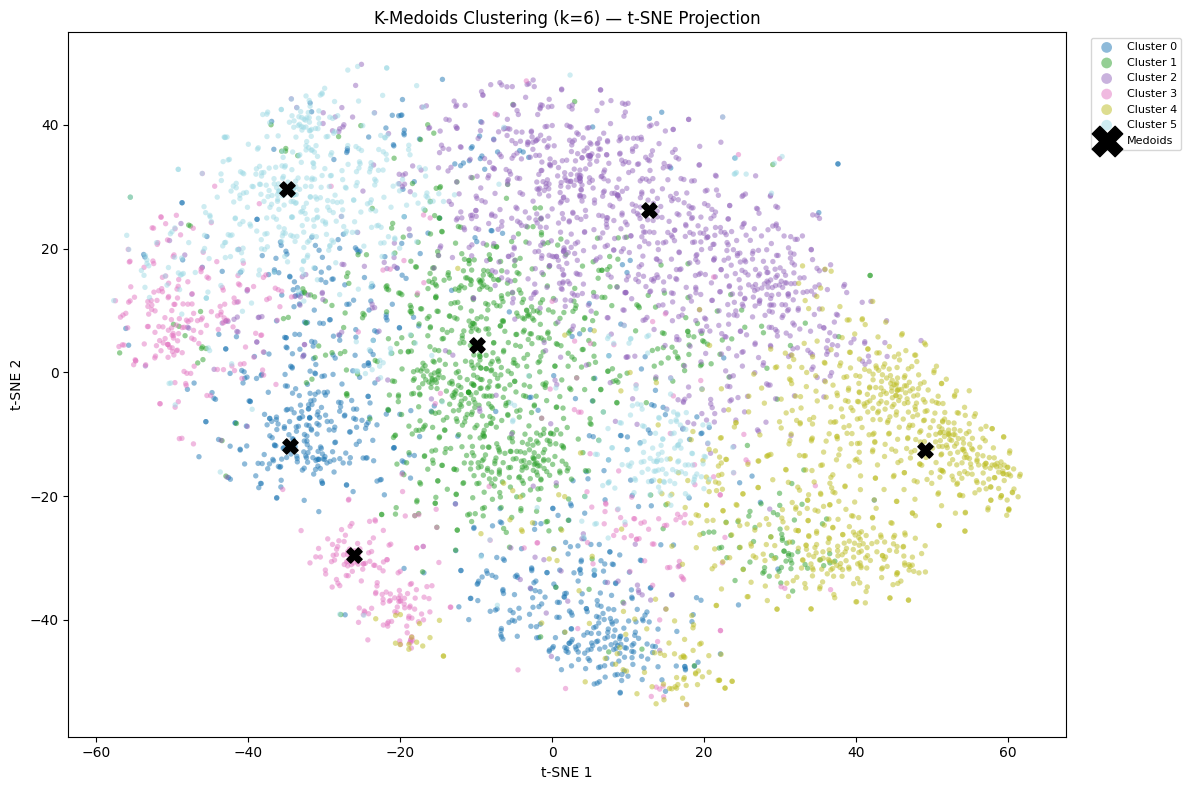

In [7]:
fig, ax = plt.subplots(figsize=(12, 8))

cmap = plt.cm.get_cmap("tab20", best_k)
for c in range(best_k):
    mask = best_labels == c
    ax.scatter(
        coords_2d[mask, 0],
        coords_2d[mask, 1],
        c=[cmap(c)],
        label=f"Cluster {c}",
        alpha=0.5,
        s=15,
        edgecolors="none",
    )

# Mark medoids
ax.scatter(
    coords_2d[best_medoids, 0],
    coords_2d[best_medoids, 1],
    c="black",
    marker="X",
    s=120,
    zorder=5,
    label="Medoids",
)

ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_title(f"K-Medoids Clustering (k={best_k}) — t-SNE Projection")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, markerscale=2)
plt.tight_layout()
plt.show()

## 5. Representative Examples per Cluster

For each cluster, show the 3 sessions closest to the medoid
and print their sub-category label sequences.

In [8]:
# Reload with extra columns needed for sequences
clf_full = pd.read_csv(
    "../data/classifications/classifications_for_analysis.csv",
    usecols=["sha", "index_in_chat", "main_category", "sub_category"],
)

# Build label-set sequences per sha (same logic as compute_distances.py)
label_sets = (
    clf_full.groupby(["sha", "index_in_chat"])
    .apply(
        lambda g: [s for s in g["sub_category"]],
        include_groups=False,
    )
    .reset_index(name="labels")
)

sha_sequences = (
    label_sets.sort_values(["sha", "index_in_chat"])
    .groupby("sha")["labels"]
    .apply(list)
    .to_dict()
)

print(f"Loaded sequences for {len(sha_sequences)} sessions")

Loaded sequences for 11579 sessions


In [9]:
N_EXAMPLES = 3

for c in range(best_k):
    medoid_idx = best_medoids[c]
    cluster_mask = np.where(best_labels == c)[0]
    cluster_size = len(cluster_mask)

    # Find top-N closest sessions to the medoid within this cluster
    dists_to_medoid = dist_matrix[medoid_idx, cluster_mask]
    nearest = np.argsort(dists_to_medoid)[:N_EXAMPLES]

    print(f"\n{'='*80}")
    print(
        f"CLUSTER {c}  |  {cluster_size} sessions  |  medoid: {shas[medoid_idx][:12]}..."
    )
    print(f"{'='*80}")

    for rank, local_idx in enumerate(nearest):
        global_idx = cluster_mask[local_idx]
        dist = dists_to_medoid[local_idx]
        sha = shas[global_idx]

        seq = sha_sequences.get(sha, [])

        print(f"\n  Example {rank+1}  (dist to medoid: {dist:.4f})")
        print(f"  SHA: {sha}")
        print(f"  Sequence length: {len(seq)}")
        for pos, labels in enumerate(seq):
            if len(labels) == 1:
                print(f"    [{pos}] {labels[0]}")
            else:
                print(f"    [{pos}] {' + '.join(labels)}")


CLUSTER 0  |  767 sessions  |  medoid: fdfe99c76903...

  Example 1  (dist to medoid: 0.0000)
  SHA: fdfe99c7690321bfb9bac771cd50fb55e725b421
  Sequence length: 5
    [0] 3.1 Planning & Decision Consultation
    [1] 3.1 Planning & Decision Consultation
    [2] 3.2 Project Comprehension
    [3] 3.1 Planning & Decision Consultation
    [4] 3.2 Project Comprehension

  Example 2  (dist to medoid: 0.2000)
  SHA: f8425e0bb7e80649b8f15ade282669979703f61f
  Sequence length: 4
    [0] 3.1 Planning & Decision Consultation
    [1] 3.1 Planning & Decision Consultation
    [2] 3.2 Project Comprehension
    [3] 3.1 Planning & Decision Consultation

  Example 3  (dist to medoid: 0.2917)
  SHA: 530fb53c0139b9d84fde09b5dd963c48dec6bade
  Sequence length: 6
    [0] 3.1 Planning & Decision Consultation
    [1] 3.1 Planning & Decision Consultation
    [2] 6.1 Documentation + 3.1 Planning & Decision Consultation
    [3] 3.2 Project Comprehension
    [4] 3.1 Planning & Decision Consultation
    [5] 6.1 Do

## Export: t-SNE Visualization Data

Exports clustering results to `data/clusters/tsne_visualization.json` for the interactive HTML visualization. Each record contains the session SHA, timestamp, cluster ID, t-SNE coordinates, and the full sub-category label sequence (multi-label messages joined with ` + `). Medoid sessions are flagged with `is_medoid: true`.

In [10]:
import json
from pathlib import Path

# ── Join timestamp from classifications ───────────────────────────────────────
ts_df = pd.read_csv(
    "../data/classifications/classifications_for_analysis.csv",
    usecols=["sha", "timestamp"],
).drop_duplicates(subset=["sha"])
sha_to_ts = ts_df.set_index("sha")["timestamp"].to_dict()

medoid_shas = set(shas[i] for i in best_medoids)

# ── Build export records ──────────────────────────────────────────────────────
records = []
for i, sha in enumerate(shas):
    seq = sha_sequences.get(sha, [])
    # Each message: list of full sub_category label strings
    # Format multi-label as "1.2 Iterative Modification + 2.2 Symptom Description"
    seq_formatted = [
        " + ".join(labels) if isinstance(labels, list) else labels for labels in seq
    ]

    records.append(
        {
            "sha": sha,
            "timestamp": sha_to_ts.get(sha, ""),
            "cluster_id": int(best_labels[i]),
            "is_medoid": sha in medoid_shas,
            "x": float(coords_2d[i, 0]),
            "y": float(coords_2d[i, 1]),
            "sequence": seq_formatted,
        }
    )

# ── Save ──────────────────────────────────────────────────────────────────────
OUT_PATH = Path("../data/clusters/tsne_visualization.json")
OUT_PATH.parent.mkdir(parents=True, exist_ok=True)

with open(OUT_PATH, "w", encoding="utf-8") as f:
    json.dump(records, f, ensure_ascii=False)

print(f"Exported {len(records)} sessions to {OUT_PATH.resolve()}")
print(f"Medoids: {sum(r['is_medoid'] for r in records)}")
print(f"Clusters: {sorted(set(r['cluster_id'] for r in records))}")
print(f"\nSample record:")
print(json.dumps(records[0], indent=2, ensure_ascii=False))

Exported 4864 sessions to /Users/ningzhi_tang/Documents/VSCodeProjects/empirical-conversational-programming/data/clusters/tsne_visualization.json
Medoids: 6
Clusters: [0, 1, 2, 3, 4, 5]

Sample record:
{
  "sha": "0006d72850c62772199e2b5f19a13badd65db90a",
  "timestamp": "2025-11-08 08:48:00",
  "cluster_id": 2,
  "is_medoid": false,
  "x": 28.403852462768555,
  "y": 16.139989852905273,
  "sequence": [
    "1.1 New Implementation + 4.1 Information Injection",
    "2.2 Symptom Description + 1.2 Iterative Modification",
    "1.2 Iterative Modification",
    "1.2 Iterative Modification",
    "1.2 Iterative Modification",
    "1.3 Alignment Correction + 1.2 Iterative Modification",
    "1.2 Iterative Modification",
    "1.2 Iterative Modification + 1.3 Alignment Correction"
  ]
}
